In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.3443.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.7971.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.10728.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.1942.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.375.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.3259.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.790.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.6319.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.10577.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.9079.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.10063.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.8013.jpg
/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train/Dog/dog.4329.jpg
/kaggle/inp

In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
print(os.listdir("/kaggle/input/datasets"))

['anubhab098']


In [5]:
print(os.listdir("/kaggle/input/datasets/anubhab098"))


['cat-vs-dog-dataset']


In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dropout,BatchNormalization,Dense,Conv2D,MaxPooling2D,Flatten

2026-05-02 10:44:47.330351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777718687.560335      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777718687.627511      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777718688.160900      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777718688.160945      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777718688.160947      57 computation_placer.cc:177] computation placer alr

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(256,256),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/anubhab098/cat-vs-dog-dataset/train',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(256,256),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1777718723.629921      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777718723.636461      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [8]:
## Now all the images are in the form of numpy arrays in the range of 0-255, so we need to normalize that
def process(image,label):
    image=tf.cast(image/255. ,tf.float32)
    return image,label
train_ds=train_ds.map(process)
validation_ds=val_ds.map(process)

In [9]:
## Create Sequential Model
model=Sequential()


model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10


I0000 00:00:1777718736.553689     140 service.cc:152] XLA service 0x79df100046f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777718736.553727     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777718736.553731     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777718737.224753     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-02 10:45:40.786985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 10:45:41.104707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/625 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.4948 - loss: 0.8388 

I0000 00:00:1777718744.532766     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - accuracy: 0.6047 - loss: 0.6508 - val_accuracy: 0.7796 - val_loss: 0.4811
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7753 - loss: 0.4752 - val_accuracy: 0.7868 - val_loss: 0.4791
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.8323 - loss: 0.3641 - val_accuracy: 0.8010 - val_loss: 0.5097
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9051 - loss: 0.2302 - val_accuracy: 0.7996 - val_loss: 0.6326
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9484 - loss: 0.1336 - val_accuracy: 0.7936 - val_loss: 0.7226
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.9742 - loss: 0.0716 - val_accuracy: 0.7850 - val_loss: 1.0251
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.9829 - loss: 0.0532 - val_accuracy: 0.7752 - val_loss: 1.3230
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.9856 - loss: 0.0441 - val_accurac

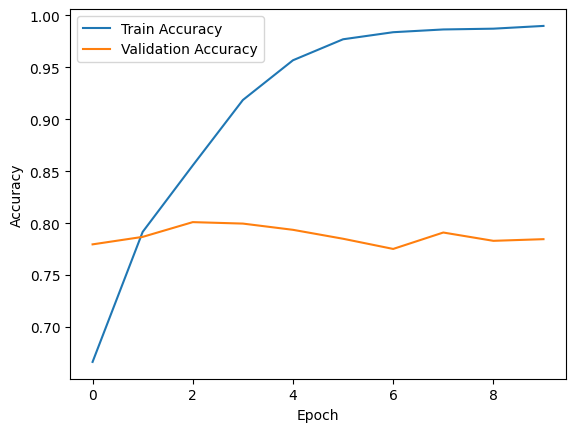

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
import requests

url = "https://images.unsplash.com/photo-1517849845537-4d257902454a"
img_path = "/kaggle/working/test.jpg"

r = requests.get(url)
with open(img_path, "wb") as f:
    f.write(r.content)

from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(img_path, target_size=(256,256))  # SAME as training
img_array = image.img_to_array(img)

# SAME normalization as your dataset
img_array = img_array.astype("float32") / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
if prediction>0.5:
    print("It is a Dog")
else:
    print("It is a cat")
    
print("Raw output:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
It is a Dog
Raw output: [[0.98146516]]


In [17]:
import requests

url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
img_path = "/kaggle/working/test.jpg"

r = requests.get(url)
with open(img_path, "wb") as f:
    f.write(r.content)

from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(img_path, target_size=(256,256))  # SAME as training
img_array = image.img_to_array(img)

# SAME normalization as your dataset
img_array = img_array.astype("float32") / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
if prediction>0.5:
    print("It is a Dog")
else:
    print("It is a cat")
    
print("Raw output:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
It is a cat
Raw output: [[3.1568474e-12]]
